# 跟着东京大学镰谷研究学习GWAS
link：https://cloufield.github.io/GWASTutorial/

# 克隆相关文件

```bash
git clone https://github.com/Cloufield/GWASTutorial.git
```

# Pre-GWAS

## 下载相关数据集
https://cloufield.github.io/GWASTutorial/01_Dataset/


```bash
cd GWASTutorial/01_Dataset
./download_sampledata.sh

# 1KG.EAS.auto.snp.norm.nodup.split.rare002.common015.missing.bed
# 1KG.EAS.auto.snp.norm.nodup.split.rare002.common015.missing.bim
# 1KG.EAS.auto.snp.norm.nodup.split.rare002.common015.missing.fam
```

### Phenotype Simulation
### 表型模拟

    Phenotypes were simply simulated using GCTA with the 1KG EAS dataset.
    使用 GCTA 和 1KG EAS 数据集简单地模拟表型。
```bash
# 下载安装acta
wget https://yanglab.westlake.edu.cn/software/gcta/bin/gcta_1.94.0beta.zip
unzip gcta_1.94.0beta.zip
ln -s gcta_1.94.0beta/gcta64 /usr/local/bin/gcta

# 运行 GCTA
gcta  \
  --bfile 1KG.EAS.auto.snp.norm.nodup.split.rare002.common015.missing \
  --simu-cc 250 254  \
  --simu-causal-loci causal.snplist  \
  --simu-hsq 0.8  \
  --simu-k 0.5  \
  --simu-rep 1  \
  --out 1kgeas_binary

# 1kgeas_binary.log
# 1kgeas_binary.par
# 1kgeas_binary.phen
```

这张图非常经典地阐释了人类遗传学中的一个核心概念：​基因变异的效应大小与其在人群中的频率之间存在一种“此消彼长”的权衡关系。
简单来说，这张图说明了：
​一个基因变异对疾病风险的影响（效应量）越大，它在人群中的频率通常就越低；反之，那些在人群中很常见的变异，对疾病风险的个体影响通常非常微小。​
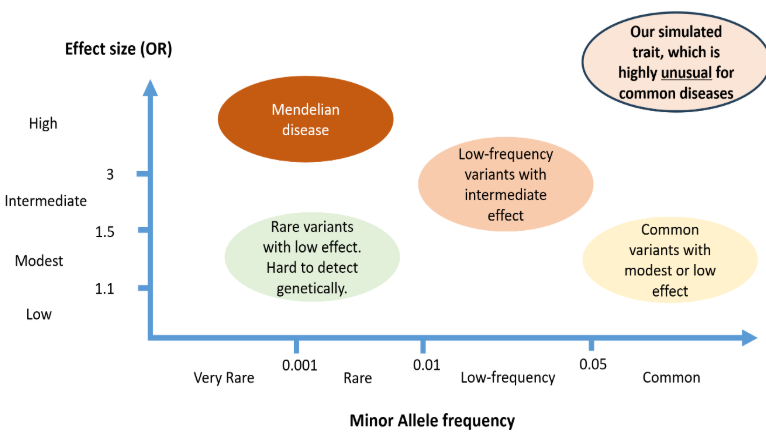
自然选择像一把筛子，效应巨大的有害变异很难在人群中传播开（频率低），而效应微小的变异则可以留存下来（频率高）。因此，疾病的遗传架构在很大程度上是由自然选择所塑造的。

## 数据格式
https://cloufield.github.io/GWASTutorial/03_Data_formats/

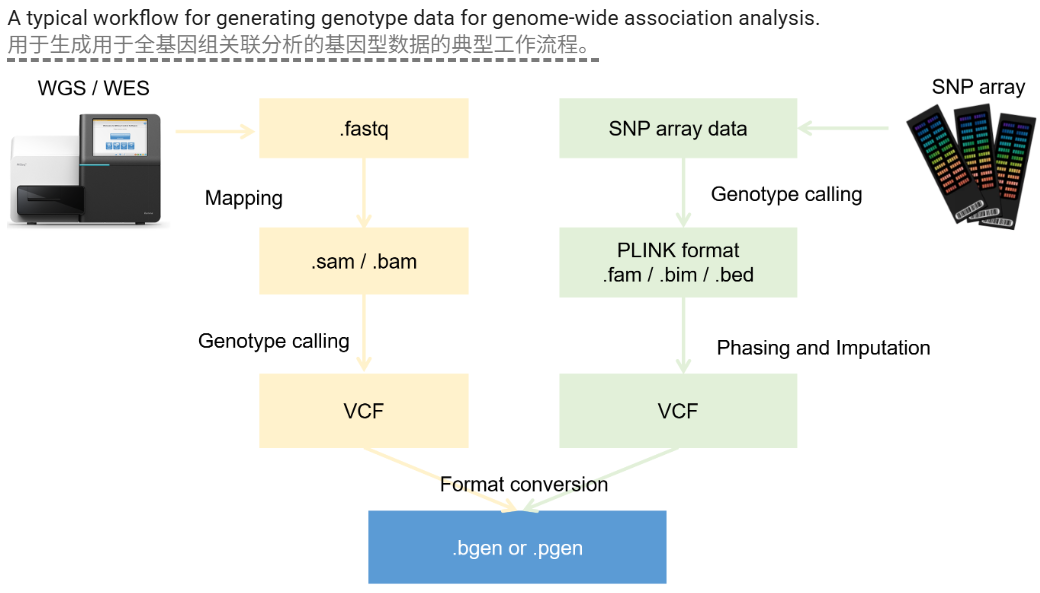
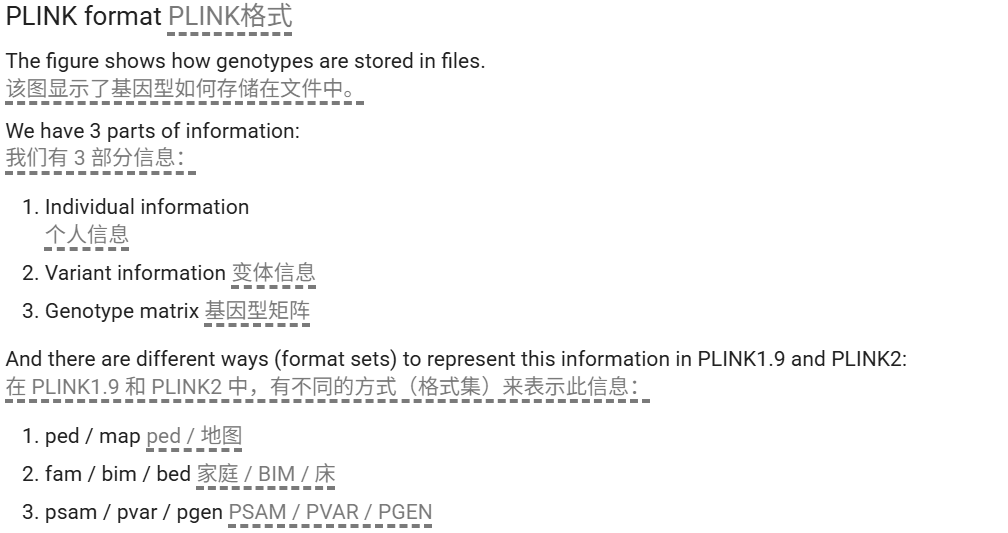
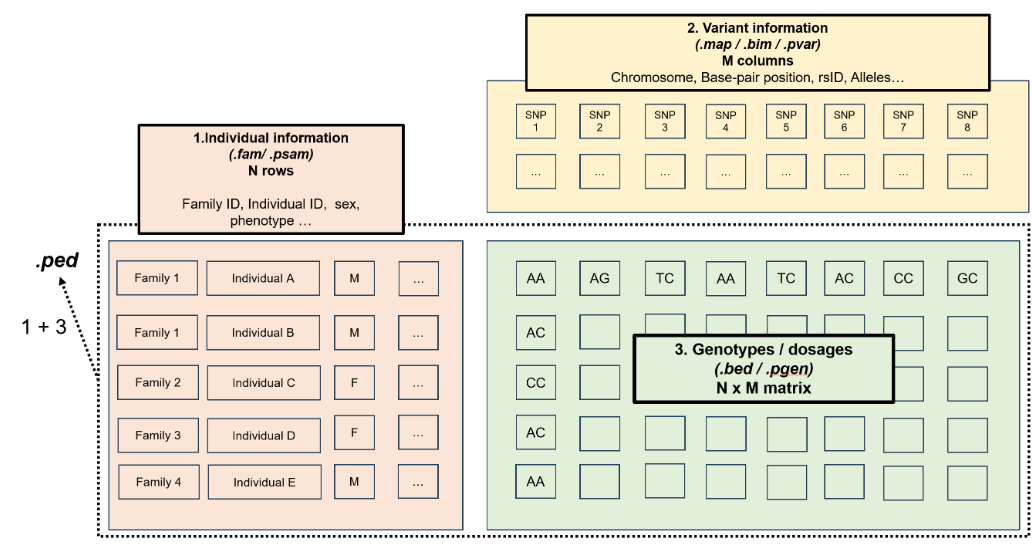

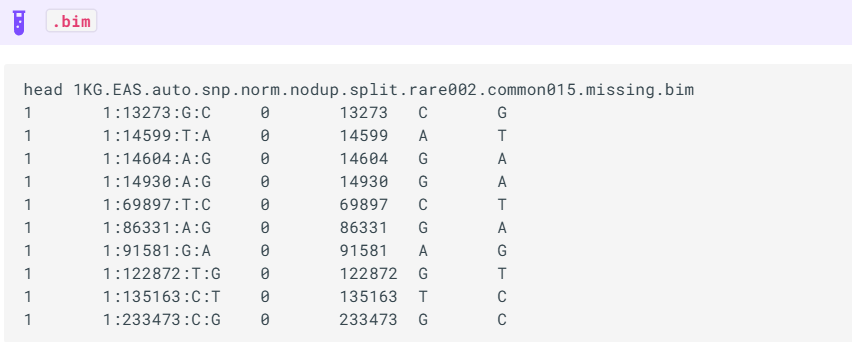

我们取截图中第一行来具体解释：

    6 rs9257672 0 32617760 C T
    ​染色体​： 6 （6号染色体）
    ​SNP ID​： rs9257672 （这是一个在 dbSNP 数据库中注册的已知位点）
    ​遗传距离​： 0 （未提供或未计算）
    ​物理位置​： 32617760 （在6号染色体的第32,617,760个碱基处）
    ​等位基因1​： C （参考等位基因是胞嘧啶）
    ​等位基因2​： T （替代等位基因是胸腺嘧啶）

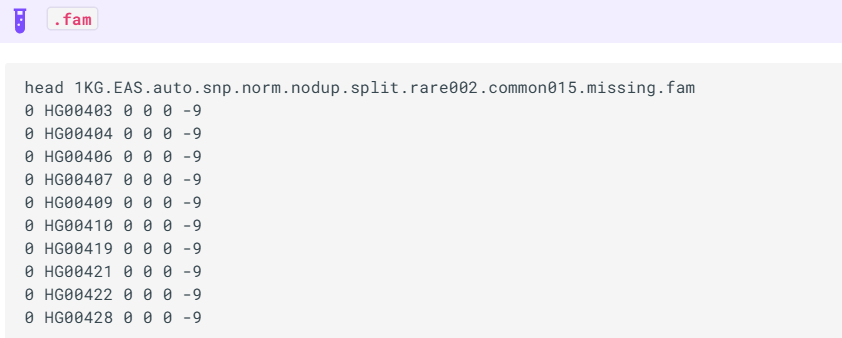

我们取截图中第一行来具体解释：

    0 HG00403 0 0 0 -9
    ​家系ID: 0（无家系信息或所有样本属于同一个“虚拟”家系）
    ​个体ID: HG00403（样本编号）
    ​父系ID: 0（父亲信息未知）
    ​母系ID: 0（母亲信息未知）
    ​性别: 0（性别未知）
    ​表型: -9（表型信息缺失）

参考资料：https://www.cog-genomics.org/plink/1.9/formats

Imputation dosage 插补剂量
bgen / bgi BGEN / BGI
参考资料：https://www.well.ox.ac.uk/~gav/bgen_format/

pgen,psam,pvar pgen，psam，pvar
参考资料：https://www.cog-genomics.org/plink/2.0/formats#pgen

注意：pgen 仅保存了每个人的剂量（标量范围从 0 到 2）。它无法转换回保存在bgen中的基因型概率（长度为3的向量）或等位基因概率（维度为2 x 2的矩阵）。
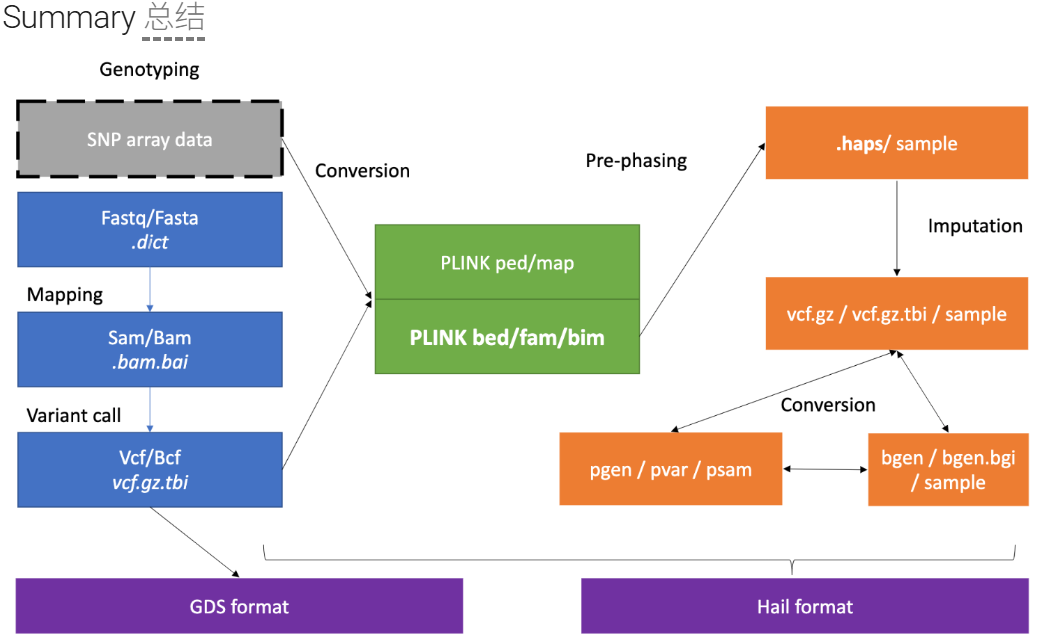

# Genotype Data QC 基因型数据质量控制
https://cloufield.github.io/GWASTutorial/04_Data_QC/

```bash
# 打开官网https://www.cog-genomics.org/plink/1.9/

# 安装plink2
wget https://s3.amazonaws.com/plink2-assets/plink2_linux_x86_64_20251019.zip
unzip plink2_linux_x86_64_20251019.zip

# 安装plink1
wget https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20250819.zip
unzip plink_linux_x86_64_20250819.zip

The functions we will learn in this tutorial:
我们将在本教程中学习的功能：

    Calculating missing rate (call rate)
    计算缺失率（呼叫率）
    Calculating allele Frequency
    计算等位基因频率
    Conducting Hardy-Weinberg equilibrium exact test
    进行 Hardy-Weinberg 平衡精确检验
    Applying filters 应用过滤器
    Conducting LD-Pruning
    进行LD修剪
    Calculating inbreeding F coefficient
    计算近亲繁殖 F 系数
    Conducting sample & SNP filtering (extract/exclude/keep/remove)
    进行样品和 SNP 过滤（提取/排除/保留/去除）
    Estimating IBD / PI_HAT
    估计 IBD / PI_HAT
    Calculating LD 计算 LD
    Data management (make-bed/recode)
    数据管理（补床/重新编码）

## 1.Calculating missing rate (call rate)
计算缺失率（呼叫率）
- 样本缺失率：单个个体在所有 SNP 中的缺失值比例。
- SNP 缺失率：所有样本中 SNP 的缺失值比例。

```bash
cd ../04_Data_QC
genotypeFile="../01_Dataset/1KG.EAS.auto.snp.norm.nodup.split.rare002.common015.missing" #!!! Please add your own path here.  "1KG.EAS.auto.snp.norm.nodup.split.rare002.common015.missing" is the prefix of PLINK bed file. 

plink \
    --bfile ${genotypeFile} \
    --missing \
    --out plink_results
```
- 此代码将生成两个文件 plink_results.imiss 和 plink_results.lmiss，分别包含样本和 SNP 的缺失率信息。

Text(0.5, 0, 'sample missing rate')

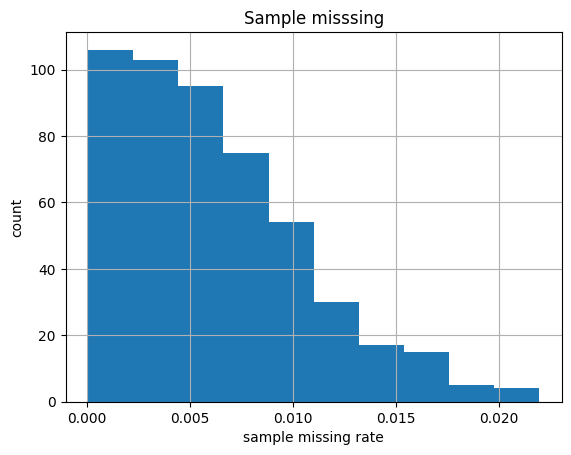

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
imiss = pd.read_csv("/mnt/d/01_study/04_GWAS教程/GWASTutorial/04_Data_QC/plink_results.imiss",sep="\s+")
imiss["F_MISS"].hist()
plt.title("Sample misssing")
plt.ylabel("count")
plt.xlabel("sample missing rate")

Text(0.5, 0, 'SNP missing rate')

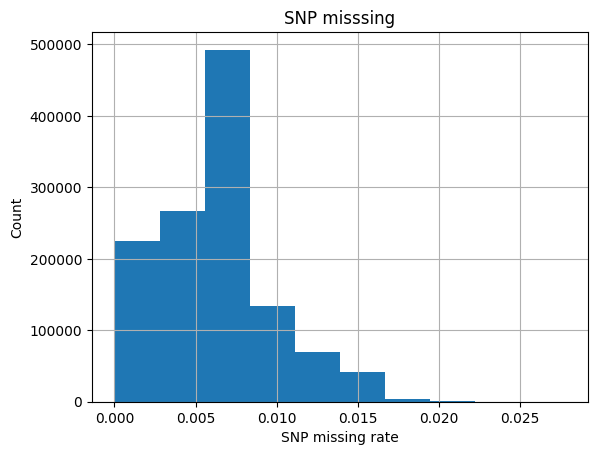

In [11]:
lmiss = pd.read_csv("/mnt/d/01_study/04_GWAS教程/GWASTutorial/04_Data_QC/plink_results.lmiss",sep="\s+")
lmiss["F_MISS"].hist()
plt.title("SNP misssing")
plt.ylabel('Count')
plt.xlabel('SNP missing rate')

## 2.Calculating allele Frequency
计算等位基因频率
- 通常，变异可以根据其次要等位基因频率 （MAF） 分为 3 组：
- 常见变体：MAF>=0.05
- 低频变体：0.01<=MAF<0.05
- 罕见变体 ： MAF<0.01

```bash
# 使用 PLINK1.9 计算变体的 MAF

plink \
    --bfile ${genotypeFile} \
    --freq \
    --out plink_results

# 输出 plink_results.frq

# 使用 plink2 

plink2 \
        --bfile ${genotypeFile} \
        --freq \
        --out plink_results

# 输出 plink_results.afreq
# 在 PLINK1.9 中，这里的概念是次要 （A1） 和主要 （A2） 等位基因，
# 而在 PLINK2 中，它是参考 （REF） 等位基因和替代 （ALT） 等位基因

## 3. Conducting Hardy-Weinberg equilibrium exact test
进行 Hardy-Weinberg 平衡精确检验

## 4.Applying filters 
应用过滤器

## 5.Conducting LD-Pruning
进行LD修剪

## 6.Calculating inbreeding F coefficient
计算近亲繁殖 F 系数

## 7.Conducting sample & SNP filtering (extract/exclude/keep/remove)
进行样品和 SNP 过滤（提取/排除/保留/去除）

## 8.Estimating IBD / PI_HAT
估计 IBD / PI_HAT

## 9.Calculating LD 
计算 LD

## 10.Data management (make-bed/recode)
数据管理